In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler,RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score,confusion_matrix,precision_score, recall_score,roc_auc_score,precision_recall_curve,balanced_accuracy_score
import optuna
import glob
import os

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-28-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/03-01-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-16-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-15-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-21-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/03-02-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-22-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-14-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-23-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/02-20-2018/02-20-2018.csv


In [3]:
selected_files = [
    "/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-14-2018.csv",
    "/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-15-2018.csv",
    "/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-16-2018.csv"
]

df_list = [pd.read_csv(f, low_memory=False) for f in selected_files]
combined_df = pd.concat(df_list, ignore_index=True)

In [4]:
combined_df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [5]:
combined_df.shape

(3145725, 80)

In [6]:
combined_df['Label'].value_counts()

Label
Benign                      2110475
DoS attacks-Hulk             461912
FTP-BruteForce               193360
SSH-Bruteforce               187589
DoS attacks-SlowHTTPTest     139890
DoS attacks-GoldenEye         41508
DoS attacks-Slowloris         10990
Label                             1
Name: count, dtype: int64

In [7]:
combined_df.isnull().sum()

Dst Port         0
Protocol         0
Timestamp        0
Flow Duration    0
Tot Fwd Pkts     0
                ..
Idle Mean        0
Idle Std         0
Idle Max         0
Idle Min         0
Label            0
Length: 80, dtype: int64

In [8]:
col=combined_df.columns
col

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [20]:
combined_df=combined_df.drop(columns='Timestamp')

In [10]:
zero_variance_cols = [col for col in combined_df.columns if combined_df[col].nunique() <= 1]
zero_variance_cols

[]

In [11]:
inf_nan_cols = combined_df.columns[
    (combined_df.isin([np.inf, -np.inf]).any(axis=0)) | (combined_df.isna().any(axis=0))
]

print(inf_nan_cols)

Index(['Flow Byts/s', 'Flow Pkts/s'], dtype='object')


In [33]:
combined_df['Flow Byts/s'] = combined_df['Flow Byts/s'].replace([np.inf, -np.inf], np.nan)
combined_df['Flow Pkts/s'] = combined_df['Flow Pkts/s'].replace([np.inf, -np.inf], np.nan)

In [34]:
combined_df['Flow Byts/s'] = combined_df['Flow Byts/s'].fillna(0)
combined_df['Flow Pkts/s'] = combined_df['Flow Pkts/s'].fillna(0)

In [14]:
inf_nan_cols = combined_df.columns[
    (combined_df.isin([np.inf, -np.inf]).any(axis=0)) | (combined_df.isna().any(axis=0))
]

print(inf_nan_cols)

Index([], dtype='object')


In [9]:
# Remove rows where Label == 'Label'
combined_df = combined_df[combined_df['Label'] != 'Label']

# Verify
print(combined_df['Label'].value_counts())

Label
Benign                      2110475
DoS attacks-Hulk             461912
FTP-BruteForce               193360
SSH-Bruteforce               187589
DoS attacks-SlowHTTPTest     139890
DoS attacks-GoldenEye         41508
DoS attacks-Slowloris         10990
Name: count, dtype: int64


In [36]:

le = LabelEncoder()

combined_df['Label'] = le.fit_transform(combined_df['Label'])

In [24]:
combined_df['Label'].value_counts()

Label
0    2110475
2     461912
5     193360
6     187589
3     139890
1      41508
4      10990
Name: count, dtype: int64

In [37]:
X = combined_df.drop('Label', axis=1)
y = combined_df['Label']

In [38]:
print(X.shape,y.shape)

(3145724, 78) (3145724,)


In [39]:
y.value_counts()

Label
0    2110475
2     461912
5     193360
6     187589
3     139890
1      41508
4      10990
Name: count, dtype: int64

In [40]:
# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

In [41]:
print(X_train.shape,X_temp.shape,y_train.shape,y_temp.shape)

(2202006, 78) (943718, 78) (2202006,) (943718,)


In [42]:
# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [43]:
X_val.shape

(471859, 78)

In [44]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [45]:
from sklearn.utils import resample

X_sample, y_sample = resample(
    X_train, y_train,
    n_samples=100000,   
    random_state=42,
    stratify=y_train
)

In [46]:
X_sample.shape

(100000, 78)

In [47]:
def objective(trial):

    C = trial.suggest_float("C", 1e-4, 10, log=True)
    max_iter = trial.suggest_int("max_iter", 200, 800)
    tol = trial.suggest_float("tol", 1e-4, 1e-2, log=True)

    model = LogisticRegression(
        C=C,
        solver="saga",          # large data
        max_iter=max_iter,
        tol=tol,
        n_jobs=-1,
        class_weight="balanced"  # for imbalance
    )

    model.fit(X_sample, y_sample)

    y_pred = model.predict(X_sample)

    score = f1_score(y_sample, y_pred, average="weighted")

    return score

In [48]:
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner()
)

[I 2026-05-01 15:20:44,835] A new study created in memory with name: no-name-171cfbb6-e62e-40a6-b211-25f825e3a217


In [49]:
print("Starting Optuna optimization ...")
study.optimize(objective, n_trials=20, n_jobs=-1, show_progress_bar=True)

print("Best parameters:", study.best_params)
print("Best score:", study.best_value)
# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=20, show_progress_bar=True)

Starting Optuna optimization ...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-01 15:22:03,617] Trial 2 finished with value: 0.683141703141617 and parameters: {'C': 9.179956387476787, 'max_iter': 292, 'tol': 0.0045022015656088635}. Best is trial 2 with value: 0.683141703141617.
[I 2026-05-01 15:22:27,547] Trial 1 finished with value: 0.6990945124161891 and parameters: {'C': 0.005310699070284305, 'max_iter': 632, 'tol': 0.0028920626452787297}. Best is trial 1 with value: 0.6990945124161891.
[I 2026-05-01 15:23:36,257] Trial 4 finished with value: 0.6973033833706428 and parameters: {'C': 0.023651927790725887, 'max_iter': 240, 'tol': 0.0033215971924423376}. Best is trial 1 with value: 0.6990945124161891.
[I 2026-05-01 15:23:55,108] Trial 5 finished with value: 0.6906168587955408 and parameters: {'C': 0.00019141009049510188, 'max_iter': 789, 'tol': 0.003347609496876629}. Best is trial 1 with value: 0.6990945124161891.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-05-01 15:24:53,503] Trial 0 finished with value: 0.7228897811502345 and parameters: {'C': 9.635145503028669, 'max_iter': 465, 'tol': 0.0003550257450490623}. Best is trial 0 with value: 0.7228897811502345.
[I 2026-05-01 15:24:57,730] Trial 7 finished with value: 0.6729732485955411 and parameters: {'C': 0.0014031196275883415, 'max_iter': 295, 'tol': 0.006015893024888273}. Best is trial 0 with value: 0.7228897811502345.


...

[I 2026-05-01 15:34:27,655] Trial 14 finished with value: 0.7223116751416652 and parameters: {'C': 8.602776925693128, 'max_iter': 453, 'tol': 0.00010627592617202275}. Best is trial 9 with value: 0.750338451518535.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-05-01 15:37:16,587] Trial 15 finished with value: 0.7431931126915169 and parameters: {'C': 0.09660511896010242, 'max_iter': 672, 'tol': 0.00010577202018786389}. Best is trial 9 with value: 0.750338451518535.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-05-01 15:38:18,718] Trial 16 finished with value: 0.769404136017997 and parameters: {'C': 0.04471065657418418, 'max_iter': 788, 'tol': 0.00013574479168589903}. Best is trial 16 with value: 0.769404136017997.
[I 2026-05-01 15:38:32,260] Trial 18 finished with value: 0.722782418661091 and parameters: {'C': 0.025769265063478687, 'max_iter': 790, 'tol': 0.001072160395599597}. Best is trial 16 with value: 0.769404136017997.
[I 2026-05-01 15:39:11,343] Trial 17 finished with value: 0.7367051833976145 and parameters: {'C': 0.019100735460325303, 'max_iter': 749, 'tol': 0.0008756344731700989}. Best is trial 16 with value: 0.769404136017997.
[I 2026-05-01 15:39:40,086] Trial 19 finished with value: 0.7107763354525918 and parameters: {'C': 0.00010006211978897615, 'max_iter': 782, 'tol': 0.0007352331624011214}. Best is trial 16 with value: 0.769404136017997.
Best parameters: {'C': 0.04471065657418418, 'max_iter': 788, 'tol': 0.00013574479168589903}
Best score: 0.769404136017997


In [50]:
print(f"Best f1_score: {study.best_trial.value:.4f}")
print(f"Best Parameters: {study.best_trial.params}")
best_params = study.best_trial.params

Best f1_score: 0.7694
Best Parameters: {'C': 0.04471065657418418, 'max_iter': 788, 'tol': 0.00013574479168589903}


In [52]:
best_params = study.best_params

final_model = LogisticRegression(
    **best_params,
    solver="saga",
    n_jobs=-1,
    class_weight="balanced"
)

final_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=0.04471065657418418, class_weight='balanced', max_iter=788,
                   n_jobs=-1, solver='saga', tol=0.00013574479168589903)

Accuracy: 0.9447
F1 Score (Weighted): 0.9470
F1 Score (Macro): 0.7793  <-- (Watch this score closely!)
ROC-AUC (OvR): 0.9935

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    316572
           1       0.60      0.83      0.70      6226
           2       0.98      0.97      0.97     69287
           3       0.62      0.55      0.58     20983
           4       0.33      0.99      0.49      1649
           5       0.70      0.78      0.74     29004
           6       0.96      1.00      0.98     28138

    accuracy                           0.94    471859
   macro avg       0.74      0.87      0.78    471859
weighted avg       0.95      0.94      0.95    471859



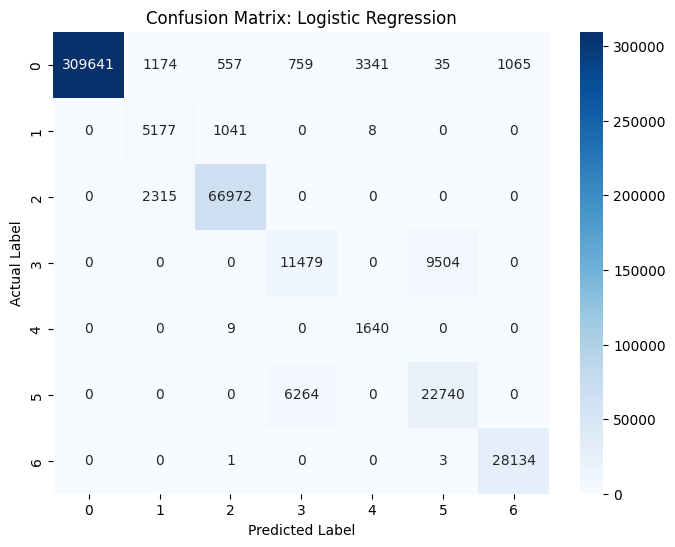

In [56]:
# 1. Generate standard predictions and probability predictions
y_test_pred_lr = final_model.predict(X_test)
y_prob_lr = final_model.predict_proba(X_test)

# 2. Calculate core metrics
acc_lr = accuracy_score(y_test, y_test_pred_lr)
f1_weighted_lr = f1_score(y_test, y_test_pred_lr, average="weighted")
f1_macro_lr = f1_score(y_test, y_test_pred_lr, average="macro")

# For multiclass ROC-AUC, we must specify multi_class="ovr" (One-vs-Rest)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr, multi_class="ovr")

# 3. Print the results
print(f"Accuracy: {acc_lr:.4f}")
print(f"F1 Score (Weighted): {f1_weighted_lr:.4f}")
print(f"F1 Score (Macro): {f1_macro_lr:.4f}  <-- (Watch this score closely!)")
print(f"ROC-AUC (OvR): {roc_auc_lr:.4f}")

# 4. Print the detailed per-class breakdown
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred_lr))

# 5. Plot the Confusion Matrix
cm_lr = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(8, 6))
# Using a 'Blues' color map for Logistic Regression to differentiate it from your XGBoost 'Greens'
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix: Logistic Regression")
plt.show()


--- Precision, Recall, and PRC Analysis ---
Precision per class:
Class 0: 1.0000
Class 1: 0.5974
Class 2: 0.9766
Class 3: 0.6204
Class 4: 0.3287
Class 5: 0.7044
Class 6: 0.9635

Recall per class:
Class 0: 0.9781
Class 1: 0.8315
Class 2: 0.9666
Class 3: 0.5471
Class 4: 0.9945
Class 5: 0.7840
Class 6: 0.9999


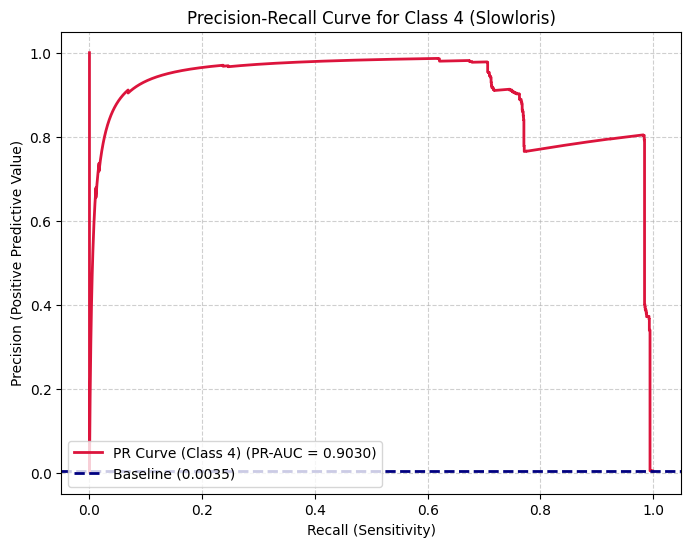

In [57]:
from sklearn.metrics import precision_score, recall_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

print("\n--- Precision, Recall, and PRC Analysis ---")

# 1. Calculate Per-Class Precision and Recall
# Using average=None returns an array with the score for every single class
precision_per_class = precision_score(y_test, y_test_pred_lr, average=None)
recall_per_class = recall_score(y_test, y_test_pred_lr, average=None)

print("Precision per class:")
for i, prec in enumerate(precision_per_class):
    print(f"Class {i}: {prec:.4f}")

print("\nRecall per class:")
for i, rec in enumerate(recall_per_class):
    print(f"Class {i}: {rec:.4f}")


# 2. Precision-Recall Curve (PRC) for a Minority Class
# Let's focus on Class 4 (DoS attacks-Slowloris) since it is highly imbalanced
class_of_interest = 4

# Create binary labels: 1 if it's the class of interest, 0 if it's anything else
y_test_binary = (y_test == class_of_interest).astype(int)

# Extract the probability predictions specifically for this class
# (y_prob_lr is the array of probabilities you generated in the previous step)
y_prob_class = y_prob_lr[:, class_of_interest]

# Calculate Precision, Recall, and the Area Under the PR Curve (PR-AUC)
precision, recall, thresholds = precision_recall_curve(y_test_binary, y_prob_class)
pr_auc = auc(recall, precision)

# 3. Plot the PR Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='crimson', lw=2, 
         label=f'PR Curve (Class {class_of_interest}) (PR-AUC = {pr_auc:.4f})')

# Add a baseline showing random guessing for this specific class
# Baseline = (Number of Class 4 samples) / (Total samples)
baseline = sum(y_test_binary) / len(y_test_binary)
plt.axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Baseline ({baseline:.4f})')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title(f'Precision-Recall Curve for Class {class_of_interest} (Slowloris)')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [58]:
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score

print("\n--- Class-wise F1 Score & Accuracy Analysis ---")

# 1. Calculate Overall and Balanced Accuracy
acc = accuracy_score(y_test, y_test_pred_lr)
bal_acc = balanced_accuracy_score(y_test, y_test_pred_lr)

print(f"Overall Accuracy:  {acc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}  <-- (More reliable for your imbalanced data)\n")

# 2. Calculate Per-Class F1-Score
# Setting average=None forces Scikit-Learn to return an array of F1-scores for every single class
f1_per_class = f1_score(y_test, y_test_pred_lr, average=None)

print("F1-Score per class:")
for i, f1 in enumerate(f1_per_class):
    # This will print the exact F1 score for Class 0, Class 1, Class 2, etc.
    print(f"Class {i}: {f1:.4f}")


--- Class-wise F1 Score & Accuracy Analysis ---
Overall Accuracy:  0.9447
Balanced Accuracy: 0.8717  <-- (More reliable for your imbalanced data)

F1-Score per class:
Class 0: 0.9889
Class 1: 0.6953
Class 2: 0.9715
Class 3: 0.5814
Class 4: 0.4941
Class 5: 0.7421
Class 6: 0.9814


In [70]:
import numpy as np
from sklearn.metrics import confusion_matrix

print("\n--- Class-wise Balanced Accuracy (LR) ---")

# 1. Generate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred_lr)

# 2. Extract True Positives (diagonal)
TP = np.diag(cm)

# 3. Calculate False Negatives (row sum minus TP)
FN = cm.sum(axis=1) - TP

# 4. Calculate False Positives (column sum minus TP)
FP = cm.sum(axis=0) - TP

# 5. Calculate True Negatives (total sum minus everything else)
TN = cm.sum() - (FP + FN + TP)

# 6. Calculate Sensitivity (Recall) and Specificity
# (Adding 1e-9 prevents division by zero if a class has no predictions)
sensitivity = TP / (TP + FN + 1e-9)
specificity = TN / (TN + FP + 1e-9)

# 7. Calculate the Class-wise Balanced Accuracy
class_balanced_accuracy = (sensitivity + specificity) / 2

# 8. Print the breakdown
for i in range(len(class_balanced_accuracy)):
    print(f"Class {i}:")
    print(f"  - Sensitivity (Recall): {sensitivity[i]:.4f}")
    print(f"  - Specificity:          {specificity[i]:.4f}")
    print(f"  - Balanced Accuracy:    {class_balanced_accuracy[i]:.4f}\n")


--- Class-wise Balanced Accuracy (LR) ---
Class 0:
  - Sensitivity (Recall): 0.9781
  - Specificity:          1.0000
  - Balanced Accuracy:    0.9891

Class 1:
  - Sensitivity (Recall): 0.8315
  - Specificity:          0.9925
  - Balanced Accuracy:    0.9120

Class 2:
  - Sensitivity (Recall): 0.9666
  - Specificity:          0.9960
  - Balanced Accuracy:    0.9813

Class 3:
  - Sensitivity (Recall): 0.5471
  - Specificity:          0.9844
  - Balanced Accuracy:    0.7657

Class 4:
  - Sensitivity (Recall): 0.9945
  - Specificity:          0.9929
  - Balanced Accuracy:    0.9937

Class 5:
  - Sensitivity (Recall): 0.7840
  - Specificity:          0.9785
  - Balanced Accuracy:    0.8812

Class 6:
  - Sensitivity (Recall): 0.9999
  - Specificity:          0.9976
  - Balanced Accuracy:    0.9987



In [ ]:
# from sklearn.model_selection import cross_val_predict

# lr_oof_probs = cross_val_predict(
#     final_model,
#     X_train,
#     y_train,
#     cv=3,
#     method='predict_proba',
#     n_jobs=-1
# )

In [ ]:
# lr_oof_probs

In [ ]:
# X_train_rf = np.column_stack((X_train, lr_oof_probs))
# print(f"Old X_train shape: {X_train.shape}")
# print(f"New X_train_rf shape (with LR prob feature): {X_train_rf.shape}")

In [ ]:
# lr_test_probs = final_model.predict_proba(X_test)

In [ ]:
# lr_test_probs

In [ ]:
# X_test_rf = np.column_stack((X_test, lr_test_probs))

In [ ]:
# print(f"Old X_train shape: {X_test.shape}")
# print(f"New X_train_rf shape (with LR prob feature): {X_test_rf.shape}")

In [ ]:
# lr_val_probs = final_model.predict_proba(X_val)

# X_val_rf = np.column_stack((X_val, lr_val_probs))

In [ ]:
# print(f"Old X_train shape: {X_val.shape}")
# print(f"New X_train_rf shape (with LR prob feature): {X_val_rf.shape}")

In [61]:
def objective_rf(trial):

    n_estimators = trial.suggest_int("n_estimators", 50, 200, step=50)
    max_depth = trial.suggest_int("max_depth", 5, 25)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

    rf_tune = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",   
        random_state=42,
        n_jobs=-1
    )

    rf_tune.fit(X_sample, y_sample)

    y_val_pred_rf = rf_tune.predict(X_val)

    return f1_score(y_val, y_val_pred_rf, average="macro")  

In [62]:
study_rf = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner()
)

[I 2026-05-01 18:58:01,866] A new study created in memory with name: no-name-2df47251-d0e0-4331-be75-bd671edefa28


In [63]:
print("\n--- Starting Optuna Optimization for Random Forest ---")
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)


--- Starting Optuna Optimization for Random Forest ---


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-01 18:58:09,296] Trial 0 finished with value: 0.8034526905709621 and parameters: {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8034526905709621.
[I 2026-05-01 18:58:13,416] Trial 1 finished with value: 0.913423190143017 and parameters: {'n_estimators': 50, 'max_depth': 22, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.913423190143017.
[I 2026-05-01 18:58:19,699] Trial 2 finished with value: 0.8604148876057043 and parameters: {'n_estimators': 100, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.913423190143017.
[I 2026-05-01 18:58:23,800] Trial 3 finished with value: 0.9133089423871661 and parameters: {'n_estimators': 50, 'max_depth': 25, 'min_samples_split': 3, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.913423190143017.
[I 2026-05-01 18:58:31,599] Trial 4 finished with value: 0.913212026933792 and parameters: {'n_estim

In [64]:
# 4. Output the best results
print(f"\nBest RF F1 Score: {study_rf.best_trial.value:.4f}")
print(f"Best RF Parameters: {study_rf.best_trial.params}")

# 5. Save the best parameters to use in our actual pipeline
best_rf_params = study_rf.best_trial.params


Best RF F1 Score: 0.9143
Best RF Parameters: {'n_estimators': 200, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 1}


In [65]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    **best_rf_params,
    class_weight="balanced", 
    n_jobs=-1,
    random_state=42
)

rf_final.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=16,
                       min_samples_split=5, n_estimators=200, n_jobs=-1,
                       random_state=42)

Accuracy: 0.9447
F1 Score (Weighted): 0.9702
F1 Score (Macro): 0.9153  <-- (Watch this score closely!)
ROC-AUC (OvR): 0.9968

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    316572
           1       1.00      1.00      1.00      6226
           2       1.00      1.00      1.00     69287
           3       0.77      0.52      0.62     20983
           4       1.00      1.00      1.00      1649
           5       0.72      0.89      0.79     29004
           6       1.00      1.00      1.00     28138

    accuracy                           0.97    471859
   macro avg       0.93      0.91      0.92    471859
weighted avg       0.97      0.97      0.97    471859



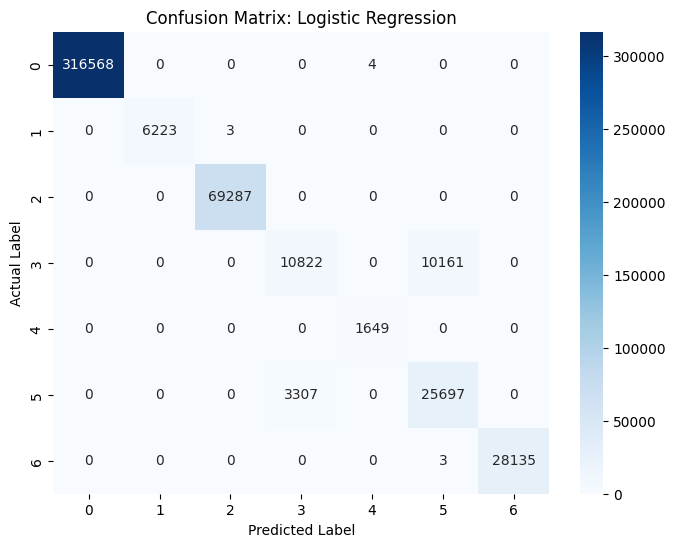

In [67]:
# 1. Generate standard predictions and probability predictions
y_test_pred_rf = rf_final.predict(X_test)
y_prob_rf = rf_final.predict_proba(X_test)

# 2. Calculate core metrics
acc_rf = accuracy_score(y_test, y_test_pred_rf)
f1_weighted_rf = f1_score(y_test, y_test_pred_rf, average="weighted")
f1_macro_rf = f1_score(y_test, y_test_pred_rf, average="macro")

# For multiclass ROC-AUC, we must specify multi_class="ovr" (One-vs-Rest)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf, multi_class="ovr")

# 3. Print the results
print(f"Accuracy: {acc_lr:.4f}")
print(f"F1 Score (Weighted): {f1_weighted_rf:.4f}")
print(f"F1 Score (Macro): {f1_macro_rf:.4f}  <-- (Watch this score closely!)")
print(f"ROC-AUC (OvR): {roc_auc_rf:.4f}")

# 4. Print the detailed per-class breakdown
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred_rf))

# 5. Plot the Confusion Matrix
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(8, 6))
# Using a 'Blues' color map for Logistic Regression to differentiate it from your XGBoost 'Greens'
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix: Logistic Regression")
plt.show()


--- Precision, Recall, and PRC Analysis ---
Precision per class:
Class 0: 1.0000
Class 1: 1.0000
Class 2: 1.0000
Class 3: 0.7659
Class 4: 0.9976
Class 5: 0.7166
Class 6: 1.0000

Recall per class:
Class 0: 1.0000
Class 1: 0.9995
Class 2: 1.0000
Class 3: 0.5158
Class 4: 1.0000
Class 5: 0.8860
Class 6: 0.9999


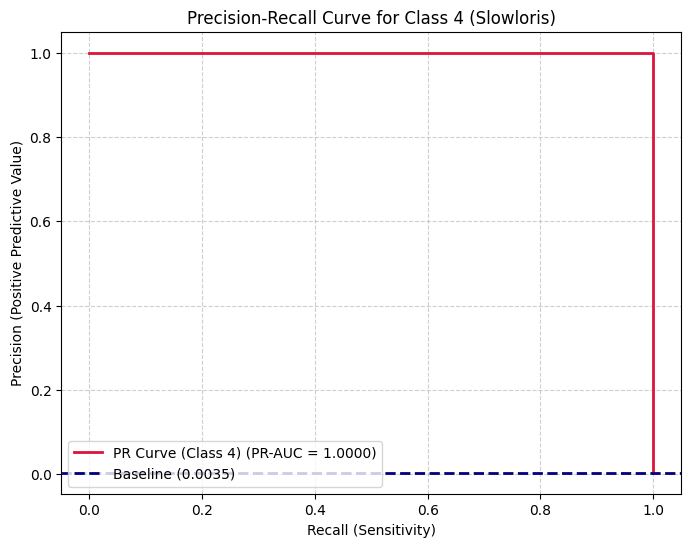

In [68]:
from sklearn.metrics import precision_score, recall_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

print("\n--- Precision, Recall, and PRC Analysis ---")

# 1. Calculate Per-Class Precision and Recall
# Using average=None returns an array with the score for every single class
precision_per_class = precision_score(y_test, y_test_pred_rf, average=None)
recall_per_class = recall_score(y_test, y_test_pred_rf, average=None)

print("Precision per class:")
for i, prec in enumerate(precision_per_class):
    print(f"Class {i}: {prec:.4f}")

print("\nRecall per class:")
for i, rec in enumerate(recall_per_class):
    print(f"Class {i}: {rec:.4f}")


# 2. Precision-Recall Curve (PRC) for a Minority Class
# Let's focus on Class 4 (DoS attacks-Slowloris) since it is highly imbalanced
class_of_interest = 4

# Create binary labels: 1 if it's the class of interest, 0 if it's anything else
y_test_binary = (y_test == class_of_interest).astype(int)

# Extract the probability predictions specifically for this class
# (y_prob_lr is the array of probabilities you generated in the previous step)
y_prob_class = y_prob_rf[:, class_of_interest]

# Calculate Precision, Recall, and the Area Under the PR Curve (PR-AUC)
precision, recall, thresholds = precision_recall_curve(y_test_binary, y_prob_class)
pr_auc = auc(recall, precision)

# 3. Plot the PR Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='crimson', lw=2, 
         label=f'PR Curve (Class {class_of_interest}) (PR-AUC = {pr_auc:.4f})')

# Add a baseline showing random guessing for this specific class
# Baseline = (Number of Class 4 samples) / (Total samples)
baseline = sum(y_test_binary) / len(y_test_binary)
plt.axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Baseline ({baseline:.4f})')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title(f'Precision-Recall Curve for Class {class_of_interest} (Slowloris)')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [69]:
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score

print("\n--- Class-wise F1 Score & Accuracy Analysis ---")

# 1. Calculate Overall and Balanced Accuracy
acc = accuracy_score(y_test, y_test_pred_rf)
bal_acc = balanced_accuracy_score(y_test, y_test_pred_rf)

print(f"Overall Accuracy:  {acc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}  <-- (More reliable for your imbalanced data)\n")

# 2. Calculate Per-Class F1-Score
# Setting average=None forces Scikit-Learn to return an array of F1-scores for every single class
f1_per_class = f1_score(y_test, y_test_pred_rf, average=None)

print("F1-Score per class:")
for i, f1 in enumerate(f1_per_class):
    # This will print the exact F1 score for Class 0, Class 1, Class 2, etc.
    print(f"Class {i}: {f1:.4f}")


--- Class-wise F1 Score & Accuracy Analysis ---
Overall Accuracy:  0.9714
Balanced Accuracy: 0.9144  <-- (More reliable for your imbalanced data)

F1-Score per class:
Class 0: 1.0000
Class 1: 0.9998
Class 2: 1.0000
Class 3: 0.6164
Class 4: 0.9988
Class 5: 0.7923
Class 6: 0.9999


In [71]:
import numpy as np
from sklearn.metrics import confusion_matrix

print("\n--- Class-wise Balanced Accuracy (LR) ---")

# 1. Generate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred_rf)

# 2. Extract True Positives (diagonal)
TP = np.diag(cm)

# 3. Calculate False Negatives (row sum minus TP)
FN = cm.sum(axis=1) - TP

# 4. Calculate False Positives (column sum minus TP)
FP = cm.sum(axis=0) - TP

# 5. Calculate True Negatives (total sum minus everything else)
TN = cm.sum() - (FP + FN + TP)

# 6. Calculate Sensitivity (Recall) and Specificity
# (Adding 1e-9 prevents division by zero if a class has no predictions)
sensitivity = TP / (TP + FN + 1e-9)
specificity = TN / (TN + FP + 1e-9)

# 7. Calculate the Class-wise Balanced Accuracy
class_balanced_accuracy = (sensitivity + specificity) / 2

# 8. Print the breakdown
for i in range(len(class_balanced_accuracy)):
    print(f"Class {i}:")
    print(f"  - Sensitivity (Recall): {sensitivity[i]:.4f}")
    print(f"  - Specificity:          {specificity[i]:.4f}")
    print(f"  - Balanced Accuracy:    {class_balanced_accuracy[i]:.4f}\n")


--- Class-wise Balanced Accuracy (LR) ---
Class 0:
  - Sensitivity (Recall): 1.0000
  - Specificity:          1.0000
  - Balanced Accuracy:    1.0000

Class 1:
  - Sensitivity (Recall): 0.9995
  - Specificity:          1.0000
  - Balanced Accuracy:    0.9998

Class 2:
  - Sensitivity (Recall): 1.0000
  - Specificity:          1.0000
  - Balanced Accuracy:    1.0000

Class 3:
  - Sensitivity (Recall): 0.5158
  - Specificity:          0.9927
  - Balanced Accuracy:    0.7542

Class 4:
  - Sensitivity (Recall): 1.0000
  - Specificity:          1.0000
  - Balanced Accuracy:    1.0000

Class 5:
  - Sensitivity (Recall): 0.8860
  - Specificity:          0.9770
  - Balanced Accuracy:    0.9315

Class 6:
  - Sensitivity (Recall): 0.9999
  - Specificity:          1.0000
  - Balanced Accuracy:    0.9999



In [ ]:
# rf_oof_probs = cross_val_predict(
#     rf_final,
#     X_train_rf,
#     y_train,
#     cv=3,
#     method='predict_proba',
#     n_jobs=-1
# )

# X_train_xgb = np.column_stack((X_train_rf, rf_oof_probs))

In [ ]:
# print(f"Old X_train shape: {X_train.shape}")
# print(f"New X_train_rf shape (with LR prob feature): {X_train_xgb.shape}")

In [ ]:
# rf_test_probs = rf_final.predict_proba(X_test_rf)
# X_test_xgb = np.column_stack((X_test_rf, rf_test_probs))

In [ ]:
# print(f"Old X_train shape: {X_test.shape}")
# print(f"New X_train_rf shape (with LR prob feature): {X_test_xgb.shape}")

In [ ]:
# rf_val_probs = rf_final.predict_proba(X_val_rf)

# X_val_xgb = np.column_stack((X_val_rf, rf_val_probs))

In [ ]:
# print(f"Old X_train shape: {X_val.shape}")
# print(f"New X_train_rf shape (with LR prob feature): {X_val_xgb.shape}")

In [72]:
def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 150, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 5),

        # Important for multiclass
        "objective": "multi:softprob",
        "num_class": len(set(y_train)),
        "eval_metric": "mlogloss",

        "random_state": 42,
        "n_jobs": -1
    }

    xgb_tune = XGBClassifier(**params)

    xgb_tune.fit(X_sample, y_sample)

    y_val_pred_xgb = xgb_tune.predict(X_val)

    return f1_score(y_val, y_val_pred_xgb, average="macro") 

In [73]:
study_xgb = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner()
)

[I 2026-05-01 19:24:07,270] A new study created in memory with name: no-name-41ac4b54-5d37-4bb3-a251-dc8c6b92390f


In [74]:
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)

  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-01 19:24:15,558] Trial 0 finished with value: 0.2683537538726647 and parameters: {'n_estimators': 50, 'max_depth': 9, 'learning_rate': 0.011557755377578364, 'subsample': 0.7557636149618029, 'colsample_bytree': 0.8212526760167578, 'reg_alpha': 0.44706252862612805, 'reg_lambda': 3.6213650426870165}. Best is trial 0 with value: 0.2683537538726647.
[I 2026-05-01 19:24:20,401] Trial 1 finished with value: 0.8741948700492602 and parameters: {'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.020546616532147777, 'subsample': 0.7081597461073229, 'colsample_bytree': 0.9020122197326971, 'reg_alpha': 0.7005636460167138, 'reg_lambda': 3.8275875891669933}. Best is trial 1 with value: 0.8741948700492602.
[I 2026-05-01 19:24:29,895] Trial 2 finished with value: 0.9138525152298511 and parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.055343011379072625, 'subsample': 0.7489039661901091, 'colsample_bytree': 0.6812962672137282, 'reg_alpha': 0.27674151389105506, 'reg_lamb

In [75]:
print(f"\nBest XGB F1 Score: {study_xgb.best_trial.value:.4f}")
print(f"Best XGB Parameters: {study_xgb.best_trial.params}")

best_xgb_params = study_xgb.best_trial.params


Best XGB F1 Score: 0.9158
Best XGB Parameters: {'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.18421248994083972, 'subsample': 0.6163276259243389, 'colsample_bytree': 0.9821209619557026, 'reg_alpha': 0.013114394390475652, 'reg_lambda': 4.9279685001508655}


In [76]:
xgb_final = XGBClassifier(
    **best_xgb_params,
    objective="multi:softprob",   
    num_class=len(set(y_train)),  
    eval_metric="mlogloss",       
    random_state=42,
    n_jobs=-1
)

In [77]:
xgb_final.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9821209619557026, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.18421248994083972,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=-1, num_class=7, ...)

Accuracy: 0.9447
F1 Score (Weighted): 0.9702
F1 Score (Macro): 0.9153  <-- (Watch this score closely!)
ROC-AUC (OvR): 0.9968

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    316572
           1       1.00      1.00      1.00      6226
           2       1.00      1.00      1.00     69287
           3       0.77      0.51      0.61     20983
           4       1.00      1.00      1.00      1649
           5       0.71      0.89      0.79     29004
           6       1.00      1.00      1.00     28138

    accuracy                           0.97    471859
   macro avg       0.93      0.91      0.92    471859
weighted avg       0.97      0.97      0.97    471859



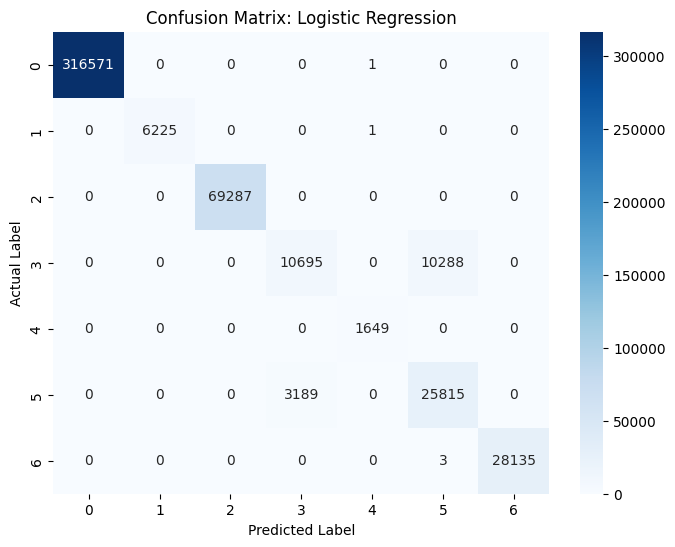

In [78]:
# 1. Generate standard predictions and probability predictions
y_test_pred_xgb = xgb_final.predict(X_test)
y_prob_xgb = xgb_final.predict_proba(X_test)

# 2. Calculate core metrics
acc_xgb = accuracy_score(y_test, y_test_pred_xgb)
f1_weighted_xgb = f1_score(y_test, y_test_pred_xgb, average="weighted")
f1_macro_xgb = f1_score(y_test, y_test_pred_xgb, average="macro")

# For multiclass ROC-AUC, we must specify multi_class="ovr" (One-vs-Rest)
roc_auc_rf = roc_auc_score(y_test, y_prob_xgb, multi_class="ovr")

# 3. Print the results
print(f"Accuracy: {acc_lr:.4f}")
print(f"F1 Score (Weighted): {f1_weighted_rf:.4f}")
print(f"F1 Score (Macro): {f1_macro_rf:.4f}  <-- (Watch this score closely!)")
print(f"ROC-AUC (OvR): {roc_auc_rf:.4f}")

# 4. Print the detailed per-class breakdown
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred_xgb))

# 5. Plot the Confusion Matrix
cm_rf = confusion_matrix(y_test, y_test_pred_xgb)

plt.figure(figsize=(8, 6))
# Using a 'Blues' color map for Logistic Regression to differentiate it from your XGBoost 'Greens'
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix: Logistic Regression")
plt.show()


--- Precision, Recall, and PRC Analysis ---
Precision per class:
Class 0: 1.0000
Class 1: 1.0000
Class 2: 1.0000
Class 3: 0.7703
Class 4: 0.9988
Class 5: 0.7150
Class 6: 1.0000

Recall per class:
Class 0: 1.0000
Class 1: 0.9998
Class 2: 1.0000
Class 3: 0.5097
Class 4: 1.0000
Class 5: 0.8900
Class 6: 0.9999


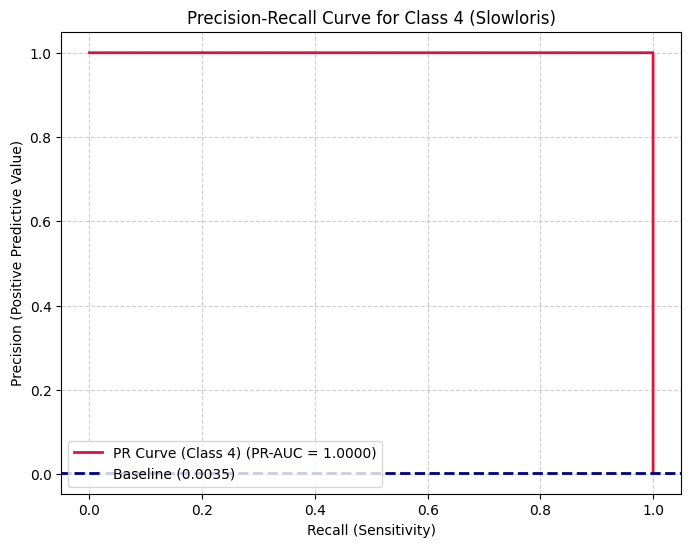

In [79]:
from sklearn.metrics import precision_score, recall_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

print("\n--- Precision, Recall, and PRC Analysis ---")

# 1. Calculate Per-Class Precision and Recall
# Using average=None returns an array with the score for every single class
precision_per_class = precision_score(y_test, y_test_pred_xgb, average=None)
recall_per_class = recall_score(y_test, y_test_pred_xgb, average=None)

print("Precision per class:")
for i, prec in enumerate(precision_per_class):
    print(f"Class {i}: {prec:.4f}")

print("\nRecall per class:")
for i, rec in enumerate(recall_per_class):
    print(f"Class {i}: {rec:.4f}")


# 2. Precision-Recall Curve (PRC) for a Minority Class
# Let's focus on Class 4 (DoS attacks-Slowloris) since it is highly imbalanced
class_of_interest = 4

# Create binary labels: 1 if it's the class of interest, 0 if it's anything else
y_test_binary = (y_test == class_of_interest).astype(int)

# Extract the probability predictions specifically for this class
# (y_prob_lr is the array of probabilities you generated in the previous step)
y_prob_class = y_prob_xgb[:, class_of_interest]

# Calculate Precision, Recall, and the Area Under the PR Curve (PR-AUC)
precision, recall, thresholds = precision_recall_curve(y_test_binary, y_prob_class)
pr_auc = auc(recall, precision)

# 3. Plot the PR Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='crimson', lw=2, 
         label=f'PR Curve (Class {class_of_interest}) (PR-AUC = {pr_auc:.4f})')

# Add a baseline showing random guessing for this specific class
# Baseline = (Number of Class 4 samples) / (Total samples)
baseline = sum(y_test_binary) / len(y_test_binary)
plt.axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Baseline ({baseline:.4f})')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title(f'Precision-Recall Curve for Class {class_of_interest} (Slowloris)')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [85]:
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score

print("\n--- Class-wise F1 Score & Accuracy Analysis ---")

# 1. Calculate Overall and Balanced Accuracy
acc = accuracy_score(y_test, y_test_pred_xgb)
bal_acc = balanced_accuracy_score(y_test, y_test_pred_xgb)

print(f"Overall Accuracy:  {acc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}  <-- (More reliable for your imbalanced data)\n")

# 2. Calculate Per-Class F1-Score
# Setting average=None forces Scikit-Learn to return an array of F1-scores for every single class
f1_per_class = f1_score(y_test, y_test_pred_xgb, average=None)

print("F1-Score per class:")
for i, f1 in enumerate(f1_per_class):
    # This will print the exact F1 score for Class 0, Class 1, Class 2, etc.
    print(f"Class {i}: {f1:.4f}")


--- Class-wise F1 Score & Accuracy Analysis ---
Overall Accuracy:  0.9714
Balanced Accuracy: 0.9142  <-- (More reliable for your imbalanced data)

F1-Score per class:
Class 0: 1.0000
Class 1: 0.9999
Class 2: 1.0000
Class 3: 0.6135
Class 4: 0.9994
Class 5: 0.7930
Class 6: 0.9999


In [ ]:
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier

# 1. Group the three models you already trained
base_models = [
    ('lr', final_model),   # Your trained Logistic Regression
    ('rf', rf_final),      # Your trained Random Forest
    ('xgb', xgb_final)     # Your trained XGBoost
]

# 2. Define the Stage 3 Meta-Learner (XGBoost)
# We keep this strictly constrained (shallow depth, high regularization) 
# so it doesn't overfit the 21 probability features generated by Level 1.
meta_model = XGBClassifier(
    n_estimators=150,
    max_depth=7,           # Shallow tree to prevent memorization
    learning_rate=0.184,
    reg_alpha=1.0,         # L1 Regularization
    reg_lambda=1.0,        # L2 Regularization
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# 3. Build the Parallel Stacking Ensemble
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=3,                            # Scikit-Learn automatically handles Out-Of-Fold routing
    stack_method='predict_proba',    # Feeds probabilities to the meta-model
    n_jobs=-1
)

print("Training the final Stage 3 Meta-Learner... (This evaluates your trained models)")

# 4. Train the ensemble on the original data
stacking_clf.fit(X_train, y_train)

Training the final Stage 3 Meta-Learner... (This evaluates your trained models)


In [86]:
import numpy as np
from sklearn.metrics import confusion_matrix

print("\n--- Class-wise Balanced Accuracy (LR) ---")

# 1. Generate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred_xgb)

# 2. Extract True Positives (diagonal)
TP = np.diag(cm)

# 3. Calculate False Negatives (row sum minus TP)
FN = cm.sum(axis=1) - TP

# 4. Calculate False Positives (column sum minus TP)
FP = cm.sum(axis=0) - TP

# 5. Calculate True Negatives (total sum minus everything else)
TN = cm.sum() - (FP + FN + TP)

# 6. Calculate Sensitivity (Recall) and Specificity
# (Adding 1e-9 prevents division by zero if a class has no predictions)
sensitivity = TP / (TP + FN + 1e-9)
specificity = TN / (TN + FP + 1e-9)

# 7. Calculate the Class-wise Balanced Accuracy
class_balanced_accuracy = (sensitivity + specificity) / 2

# 8. Print the breakdown
for i in range(len(class_balanced_accuracy)):
    print(f"Class {i}:")
    print(f"  - Sensitivity (Recall): {sensitivity[i]:.4f}")
    print(f"  - Specificity:          {specificity[i]:.4f}")
    print(f"  - Balanced Accuracy:    {class_balanced_accuracy[i]:.4f}\n")


--- Class-wise Balanced Accuracy (LR) ---
Class 0:
  - Sensitivity (Recall): 1.0000
  - Specificity:          1.0000
  - Balanced Accuracy:    1.0000

Class 1:
  - Sensitivity (Recall): 0.9998
  - Specificity:          1.0000
  - Balanced Accuracy:    0.9999

Class 2:
  - Sensitivity (Recall): 1.0000
  - Specificity:          1.0000
  - Balanced Accuracy:    1.0000

Class 3:
  - Sensitivity (Recall): 0.5097
  - Specificity:          0.9929
  - Balanced Accuracy:    0.7513

Class 4:
  - Sensitivity (Recall): 1.0000
  - Specificity:          1.0000
  - Balanced Accuracy:    1.0000

Class 5:
  - Sensitivity (Recall): 0.8900
  - Specificity:          0.9768
  - Balanced Accuracy:    0.9334

Class 6:
  - Sensitivity (Recall): 0.9999
  - Specificity:          1.0000
  - Balanced Accuracy:    0.9999



In [ ]:
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier

# 1. Group the three models you already trained
base_models = [
    ('lr', final_model),   # Your trained Logistic Regression
    ('rf', rf_final),      # Your trained Random Forest
    ('xgb', xgb_final)     # Your trained XGBoost
]

# 2. Define the Stage 3 Meta-Learner (XGBoost)
# We keep this strictly constrained (shallow depth, high regularization) 
# so it doesn't overfit the 21 probability features generated by Level 1.
meta_model = XGBClassifier(
    n_estimators=180,
    max_depth=7,           # Shallow tree to prevent memorization
    learning_rate=0.18423,
    reg_alpha=1.0,         # L1 Regularization
    reg_lambda=1.0,        # L2 Regularization
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# 3. Build the Parallel Stacking Ensemble
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=3,                            # Scikit-Learn automatically handles Out-Of-Fold routing
    stack_method='predict_proba',    # Feeds probabilities to the meta-model
    n_jobs=-1
)

print("Training the final Stage 3 Meta-Learner... (This evaluates your trained models)")

# 4. Train the ensemble on the original data
stacking_clf.fit(X_train, y_train)

print("Ensemble Training Complete!")

In [88]:
import joblib

# 1. Save the Logistic Regression model
joblib.dump(final_model, 'logistic_regression_model.pkl')

# 2. Save the Random Forest model
joblib.dump(rf_final, 'random_forest_model.pkl')

# 3. Save the XGBoost model
joblib.dump(xgb_final, 'xgboost_model.pkl')

print("All three models have been saved as separate files!")

All three models have been saved as separate files!
